[Voter.vote] Esther is voting for George.
[VotingSystem.record_vote] Vote recorded for George.
[Admin.view_results] Election Officer is viewing results.
[VotingSystem.get_results] Returning vote counts.


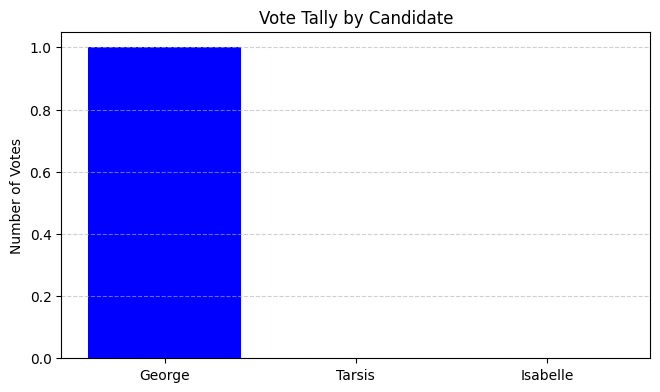

In [ ]:
import tkinter as tk
from tkinter import messagebox
# Import for graphing
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
# Import for explicit Abstraction
from abc import ABC, abstractmethod # <-- NEW IMPORT

# Base class: 
# Inherit from ABC to make this an Abstract Base Class
class User(ABC): 
    # The rest of __init__ is Encapsulation
    def __init__(self, user_id, name):
        self._user_id = user_id 
        self._name = name

    @abstractmethod #Makes this method abstract
    def get_details(self): 
        """Forces subclasses (Voter, Admin) to implement this method."""
        print(f"[User.get_details] Returning user info for {self._name}")
        # Abstraction: Base implementation is generally not used, but kept for clarity
        return f"User ID: {self._user_id}, Name: {self._name}"
    
# Subclass: 
class Voter(User): 
    def __init__(self, user_id, name):
        super().__init__(user_id, name)
        self._has_voted = False

    def vote(self, candidate, system):
        if self._has_voted:
            print(f"[Voter.vote] {self._name} has already voted.")
        else:
            print(f"[Voter.vote] {self._name} is voting for {candidate}.")
            system.record_vote(candidate)
            self._has_voted = True

    # This method is now MANDATORY because it was decorated with @abstractmethod in User
    def get_details(self): # (Inheritance/Polymorphism)
        print(f"[Voter.get_details] Returning voter info for {self._name}")
        status = "Voted" if self._has_voted else "Not Voted"
        # We call super().get_details() to reuse the base class's string formatting
        return super().get_details() + f", Status: {status}"

# Subclass: Admin 
class Admin(User): 
    def __init__(self, user_id, name):
        super().__init__(user_id, name)

    def view_results(self, system):
        print(f"[Admin.view_results] {self._name} is viewing results.")
        return system.get_results()

    # This method is also MANDATORY
    def get_details(self): # (Inheritance/Polymorphism)
        print(f"[Admin.get_details] Returning admin info for {self._name}")
        # We call super().get_details() to reuse the base class's string formatting
        return super().get_details() + " (Admin)"

# ... (The rest of your code - VotingSystem and E_VotingApp - remains the same)

# Voting System
class VotingSystem:
    def __init__(self, candidates): #initialize with a list of candidates
        self._candidates = candidates #stores names and initializes voter counts
        self._votes = {candidate: 0 for candidate in candidates}

    def record_vote(self, candidate): #record a vote.
        if candidate in self._votes:
            self._votes[candidate] += 1 #increments vote count
            print(f"[VotingSystem.record_vote] Vote recorded for {candidate}.")
        else: #handling invalid candidates names
            print(f"[VotingSystem.record_vote] Invalid candidate: {candidate}")

    def get_results(self): #returning voting tally
        print("[VotingSystem.get_results] Returning vote counts.")
        return self._votes

class E_VotingApp:
    def __init__(self, root):
        self.root = root
        self.root.title("E-Voting System")
        # 1. INCREASE GUI SIZE: Set a larger initial size for the main window
        self.root.geometry("600x400") 
        
        self.voting_system = VotingSystem(["Tarsis", "Isabelle", "George"])
        # Predefined voters and admins to separate roles
        self.voters = {
            1: Voter(1, "Esther"),
            2: Voter(2, "Joy"),
            3: Voter(3, "Humble"),
            4: Voter(4, "Alice"),
            5: Voter(5, "Bob")
        }
        self.admins = {
            99: Admin(99, "Election Officer")
        }
        
        # Clear main window content
        for widget in self.root.winfo_children():
            widget.destroy()

        # Main menu (Centered for the larger window)
        main_frame = tk.Frame(self.root)
        main_frame.pack(expand=True, padx=50, pady=50)
        
        tk.Button(main_frame, text="Login as Voter", command=self.voter_login, font=('Arial', 14), width=20, height=2).pack(pady=20)
        tk.Button(main_frame, text="Login as Admin", command=self.admin_login, font=('Arial', 14), width=20, height=2).pack(pady=20)

    def voter_login(self):
        login_win = tk.Toplevel(self.root)
        login_win.title("Voter Login")
        login_win.geometry("400x250") # Set size for login window

        tk.Label(login_win, text="User ID:").pack(pady=5)
        id_entry = tk.Entry(login_win)
        id_entry.pack(pady=5)

        tk.Label(login_win, text="Name:").pack(pady=5)
        name_entry = tk.Entry(login_win)
        name_entry.pack(pady=5)

        def submit():
            try:
                user_id = int(id_entry.get())
                name = name_entry.get().strip()
                if not name:
                    messagebox.showerror("Error", "Name cannot be empty")
                    return
                if user_id not in self.voters:
                    messagebox.showerror("Error", "Invalid Voter ID")
                    return
                voter = self.voters[user_id]
                if voter._name != name:
                    messagebox.showerror("Error", "Name mismatch for this ID")
                    return
                login_win.destroy()
                self.voter_dashboard(voter)
            except ValueError:
                messagebox.showerror("Error", "User ID must be an integer")

        tk.Button(login_win, text="Submit", command=submit).pack(pady=10)

    def voter_dashboard(self, voter):
        if voter._has_voted:
            messagebox.showinfo("Info", "You have already voted.")
            return

        dash_win = tk.Toplevel(self.root)
        dash_win.title("Voter Dashboard")
        dash_win.geometry("500x400") # Increased height to accommodate radio buttons

        tk.Label(dash_win, text=f"Welcome, {voter._name}", font=('Arial', 12, 'bold')).pack(pady=10)
        tk.Label(dash_win, text="**Select Candidate:** (You can only vote once)", font=('Arial', 10)).pack(pady=5)

        if not self.voting_system._candidates:
            tk.Label(dash_win, text="No candidates available for voting.", fg="red").pack(pady=10)
            return

        # --- MODIFICATION START: Replacing Dropdown with Radiobuttons ---
        
        # Variable to hold the selected candidate name
        candidate_var = tk.StringVar(dash_win)
        
        # Set a default value (important for radio buttons)
        candidate_var.set(self.voting_system._candidates[0]) 
        
        # Frame to hold the radio buttons
        radio_frame = tk.Frame(dash_win, padx=20, pady=10, relief=tk.GROOVE, borderwidth=1)
        radio_frame.pack(pady=10, padx=50, fill="x")

        # Create a radio button for each candidate
        for i, candidate in enumerate(self.voting_system._candidates):
            # The value of the radio button is the candidate's name
            rb = tk.Radiobutton(
                radio_frame, 
                text=candidate, 
                variable=candidate_var, 
                value=candidate,
                font=('Arial', 12),
                anchor="w", # Align text to the west (left)
                width=30 # Give a consistent width
            )
            rb.pack(anchor="w") # Pack each radio button aligned to the left side of the frame

        # --- MODIFICATION END ---
        
        def vote():
            cand = candidate_var.get()
            if not cand:
                 messagebox.showerror("Error", "Please select a candidate.")
                 return
                 
            # Ensure the selected candidate is a valid choice (which it should be with radio buttons)
            if cand in self.voting_system._candidates:
                voter.vote(cand, self.voting_system)
                dash_win.destroy()
                messagebox.showinfo("Success", "Vote cast successfully")
            else:
                 # Should not happen with radio buttons, but for safety
                messagebox.showerror("Error", "Invalid candidate selected.")

        tk.Button(dash_win, text="Cast Vote Securely", command=vote, font=('Arial', 12, 'bold'), width=25, bg='light green').pack(pady=30)

    def admin_login(self):
        login_win = tk.Toplevel(self.root)
        login_win.title("Admin Login")
        login_win.geometry("400x250") # Set size for login window

        tk.Label(login_win, text="User ID:").pack(pady=5)
        id_entry = tk.Entry(login_win)
        id_entry.pack(pady=5)

        tk.Label(login_win, text="Name:").pack(pady=5)
        name_entry = tk.Entry(login_win)
        name_entry.pack(pady=5)

        def submit():
            try:
                user_id = int(id_entry.get())
                name = name_entry.get().strip()
                if not name:
                    messagebox.showerror("Error", "Name cannot be empty")
                    return
                if user_id not in self.admins:
                    messagebox.showerror("Error", "Invalid Admin ID")
                    return
                admin = self.admins[user_id]
                if admin._name != name:
                    messagebox.showerror("Error", "Name mismatch for this ID")
                    return
                login_win.destroy()
                self.admin_dashboard(admin)
            except ValueError:
                messagebox.showerror("Error", "User ID must be an integer")

        tk.Button(login_win, text="Submit", command=submit).pack(pady=10)

    def admin_dashboard(self, admin):
        dash_win = tk.Toplevel(self.root)
        dash_win.title("Admin Dashboard")
        dash_win.geometry("600x500") # Set a large size for admin dashboard

        tk.Label(dash_win, text=f"Welcome, Admin {admin._name}", font=('Arial', 14, 'bold')).pack(pady=15)
        
        # Frame for adding candidate
        cand_frame = tk.LabelFrame(dash_win, text="Candidate Management", padx=10, pady=10)
        cand_frame.pack(pady=10, padx=50, fill="x")

        tk.Label(cand_frame, text="Add New Candidate:").pack(side=tk.LEFT, padx=5)
        cand_entry = tk.Entry(cand_frame, width=20)
        cand_entry.pack(side=tk.LEFT, padx=5, expand=True)

        def add_cand():
            new_cand = cand_entry.get().strip()
            if not new_cand:
                messagebox.showerror("Error", "Candidate name cannot be empty")
                return
            if new_cand in self.voting_system._candidates:
                messagebox.showerror("Error", "Candidate already exists")
                return
            self.voting_system._candidates.append(new_cand)
            self.voting_system._votes[new_cand] = 0
            messagebox.showinfo("Success", f"Candidate '{new_cand}' added")
            cand_entry.delete(0, tk.END)

        tk.Button(cand_frame, text="Add Candidate", command=add_cand).pack(side=tk.RIGHT, padx=5)

        # View results button
        tk.Button(dash_win, text="View Election Results (with Graph)", command=lambda: self.view_results_graph(admin), font=('Arial', 12), width=30).pack(pady=20)

    # NEW FUNCTION: Replace the simple messagebox with a full results window containing a graph
    def view_results_graph(self, admin):
        results = admin.view_results(self.voting_system)
        
        results_win = tk.Toplevel(self.root)
        results_win.title("Election Results")
        results_win.geometry("800x600") # Large window for the graph
        results_win.grab_set() # Modal window

        tk.Label(results_win, text="Current Election Results", font=('Arial', 16, 'bold')).pack(pady=10)
        
        # Prepare data for graph (Sort by votes descending)
        sorted_results = dict(sorted(results.items(), key=lambda item: item[1], reverse=True))
        candidates = list(sorted_results.keys())
        votes = list(sorted_results.values())

        # 2. ADD GRAPHS: Create the matplotlib figure and a bar chart
        fig, ax = plt.subplots(figsize=(7, 4)) # Adjust figure size for the window
        ax.bar(candidates, votes, color=['blue', 'green', 'red', 'purple', 'orange'][:len(candidates)])
        ax.set_ylabel('Number of Votes')
        ax.set_title('Vote Tally by Candidate')
        
        # Add a light grid for better readability
        ax.yaxis.grid(True, linestyle='--', alpha=0.6) 

        # Embed the matplotlib graph into the Tkinter window
        canvas = FigureCanvasTkAgg(fig, master=results_win)
        canvas_widget = canvas.get_tk_widget()
        canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=1, padx=20, pady=10)
        canvas.draw()
        

        # Display raw vote counts below the graph
        res_str = "Raw Vote Counts:\n"
        for c, v in sorted_results.items():
            res_str += f"{c}: {v} votes\n"
        
        tk.Label(results_win, text=res_str, justify=tk.LEFT, font=('Courier', 10)).pack(pady=10, padx=20)
        
if __name__ == "__main__":
    root = tk.Tk()
    app = E_VotingApp(root)
    root.mainloop()